# 0 Importul si incarcarea datelor

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
df = pd.read_csv("../dataset/clienti.csv")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              300 non-null    object 
 1   Segment                 300 non-null    object 
 2   Region                  300 non-null    object 
 3   Age                     300 non-null    int64  
 4   Gender                  300 non-null    object 
 5   TenureMonths            300 non-null    int64  
 6   PlanType                300 non-null    object 
 7   NumServices             300 non-null    int64  
 8   MonthlyRevenue          300 non-null    float64
 9   NumTicketsLast6M        300 non-null    int64  
 10  AvgResolutionTimeHours  300 non-null    float64
 11  LatePaymentsLast6M      300 non-null    int64  
 12  Autopay                 300 non-null    int64  
 13  SatisfactionScore       300 non-null    float64
 14  Churn                   300 non-null    in

# 1. Analiză descriptivă

## 1.1 Calculați indicatori descriptivi

In [18]:
cols = ["MonthlyRevenue", "Age", "TenureMonths", "SatisfactionScore"]

descriptive_stats = df[cols].agg(
    ["mean", "median", "min", "max", "std"]
).T  # .T pentru a avea variabilele pe rânduri

# redenumesc rândurile în română (opțional)
descriptive_stats.rename(
    columns={
        "mean": "Medie",
        "median": "Mediana",
        "min": "Minim",
        "max": "Maxim",
        "std": "Deviație standard"
    },
    inplace=True
)

display(descriptive_stats)

,Medie,Mediana,Minim,Maxim,Deviație standard
MonthlyRevenue,81.263867,67.28,8.62,303.2,55.869213
Age,45.680000,46.00,18.00,74.0,16.706925
TenureMonths,32.280000,34.00,1.00,60.0,16.581458
SatisfactionScore,7.106000,7.10,3.60,9.9,1.047611


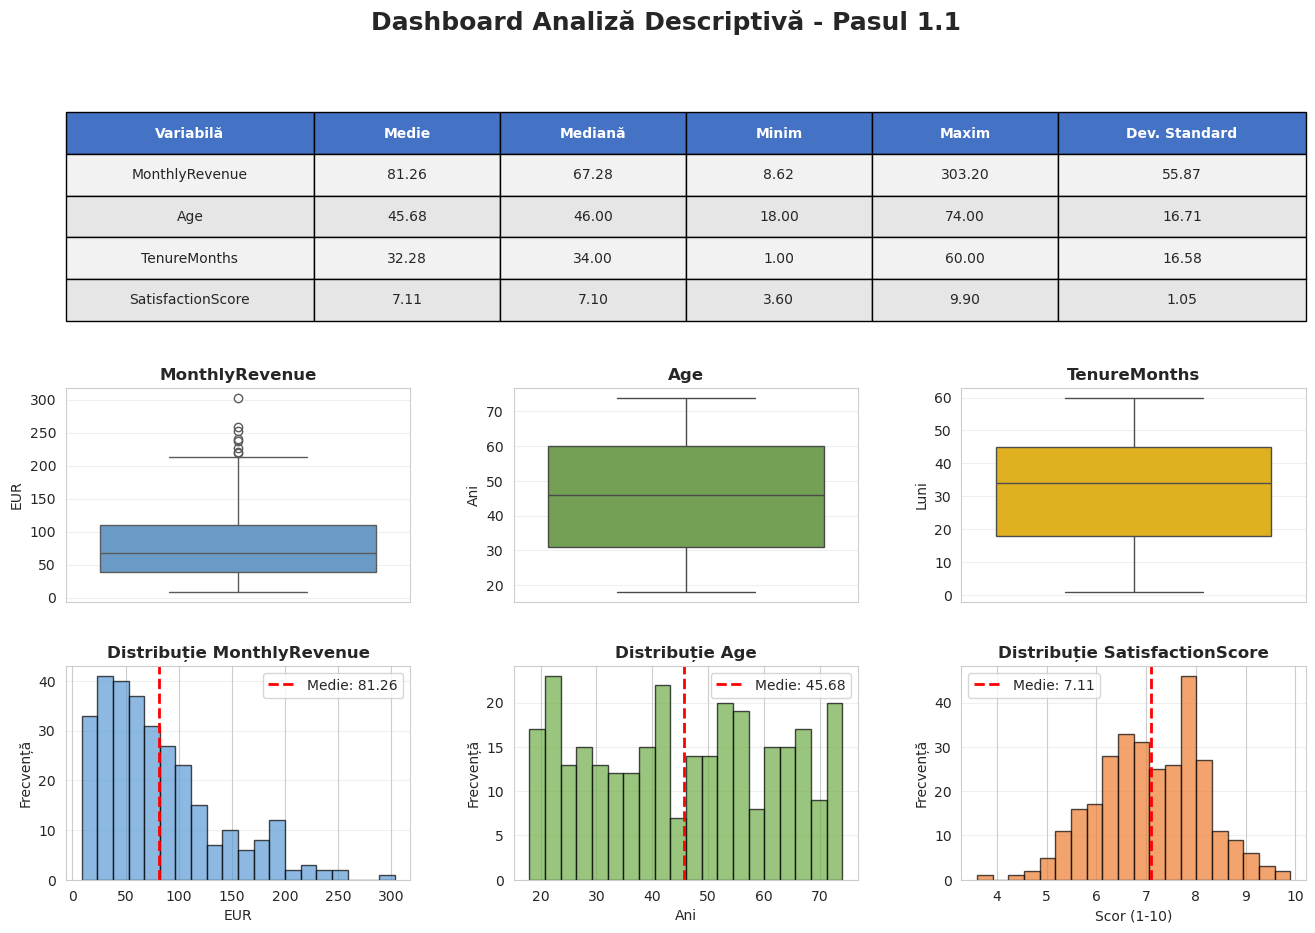


📊 Dashboard generat cu succes!

💡 Notă: Acesta folosește date fictive pentru demonstrație.
   Pentru datele tale reale, înlocuiește cu: df = pd.read_csv('../dataset/clienti.csv')


In [26]:
cols = ["MonthlyRevenue", "Age", "TenureMonths", "SatisfactionScore"]

descriptive_stats = df[cols].agg(
    ["mean", "median", "min", "max", "std"]
).T

descriptive_stats.rename(
    columns={
        "mean": "Medie",
        "median": "Mediană",
        "min": "Minim",
        "max": "Maxim",
        "std": "Deviație standard"
    },
    inplace=True
)

# Rotunjesc valorile pentru afișare mai clară
descriptive_stats = descriptive_stats.round(2)

# Creez dashboard-ul
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Setez stilul seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")

# Titlu principal
fig.suptitle('Dashboard Analiză Descriptivă - Pasul 1.1', fontsize=18, fontweight='bold', y=0.98)

# 1. Tabel cu indicatori descriptivi (ocupă prima linie)
ax_table = fig.add_subplot(gs[0, :])
ax_table.axis('tight')
ax_table.axis('off')

table_data = []
table_data.append(['Variabilă', 'Medie', 'Mediană', 'Minim', 'Maxim', 'Dev. Standard'])
for idx, row in descriptive_stats.iterrows():
    table_data.append([idx, f"{row['Medie']:.2f}", f"{row['Mediană']:.2f}", 
                      f"{row['Minim']:.2f}", f"{row['Maxim']:.2f}", f"{row['Deviație standard']:.2f}"])

table = ax_table.table(cellText=table_data, cellLoc='center', loc='center',
                       colWidths=[0.2, 0.15, 0.15, 0.15, 0.15, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Stilizez header-ul
for i in range(6):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternez culorile rândurilor
for i in range(1, len(table_data)):
    for j in range(6):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('#F2F2F2')

# 2. Boxplot pentru MonthlyRevenue
ax1 = fig.add_subplot(gs[1, 0])
sns.boxplot(y=df['MonthlyRevenue'], ax=ax1, color='#5B9BD5')
ax1.set_ylabel('EUR', fontsize=10)
ax1.set_title('MonthlyRevenue', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 3. Boxplot pentru Age
ax2 = fig.add_subplot(gs[1, 1])
sns.boxplot(y=df['Age'], ax=ax2, color='#70AD47')
ax2.set_ylabel('Ani', fontsize=10)
ax2.set_title('Age', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 4. Boxplot pentru TenureMonths
ax3 = fig.add_subplot(gs[1, 2])
sns.boxplot(y=df['TenureMonths'], ax=ax3, color='#FFC000')
ax3.set_ylabel('Luni', fontsize=10)
ax3.set_title('TenureMonths', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 5. Histogramă pentru MonthlyRevenue
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(df['MonthlyRevenue'], bins=20, color='#5B9BD5', alpha=0.7, edgecolor='black')
ax4.axvline(df['MonthlyRevenue'].mean(), color='red', linestyle='--', linewidth=2, label=f'Medie: {df["MonthlyRevenue"].mean():.2f}')
ax4.set_xlabel('EUR', fontsize=10)
ax4.set_ylabel('Frecvență', fontsize=10)
ax4.set_title('Distribuție MonthlyRevenue', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 6. Histogramă pentru Age
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(df['Age'], bins=20, color='#70AD47', alpha=0.7, edgecolor='black')
ax5.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Medie: {df["Age"].mean():.2f}')
ax5.set_xlabel('Ani', fontsize=10)
ax5.set_ylabel('Frecvență', fontsize=10)
ax5.set_title('Distribuție Age', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# 7. Histogramă pentru SatisfactionScore
ax6 = fig.add_subplot(gs[2, 2])
ax6.hist(df['SatisfactionScore'], bins=20, color='#ED7D31', alpha=0.7, edgecolor='black')
ax6.axvline(df['SatisfactionScore'].mean(), color='red', linestyle='--', linewidth=2, label=f'Medie: {df["SatisfactionScore"].mean():.2f}')
ax6.set_xlabel('Scor (1-10)', fontsize=10)
ax6.set_ylabel('Frecvență', fontsize=10)
ax6.set_title('Distribuție SatisfactionScore', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.savefig("../figures/dashboard_analiza_descriptiva.pdf", bbox_inches='tight')
plt.show()

print("\n📊 Dashboard generat cu succes!")
print("\n💡 Notă: Acesta folosește date fictive pentru demonstrație.")
print("   Pentru datele tale reale, înlocuiește cu: df = pd.read_csv('../dataset/clienti.csv')")

## 1.2 Construiți tabele de frecvență

In [28]:
# 2. Tabele de frecvență simple (număr clienți)
freq_plan = df["PlanType"].value_counts().rename("NumarClienti")
freq_segment = df["Segment"].value_counts().rename("NumarClienti")
freq_region = df["Region"].value_counts().rename("NumarClienti")

# 3. Adăugăm și procentul (procente din total)
freq_plan_pct = df["PlanType"].value_counts(normalize=True).mul(100).round(2).rename("Procent")
freq_segment_pct = df["Segment"].value_counts(normalize=True).mul(100).round(2).rename("Procent")
freq_region_pct = df["Region"].value_counts(normalize=True).mul(100).round(2).rename("Procent")

# 4. Combinăm număr + procent într-un singur tabel pentru fiecare variabilă
tab_plan = pd.concat([freq_plan, freq_plan_pct], axis=1)
tab_segment = pd.concat([freq_segment, freq_segment_pct], axis=1)
tab_region = pd.concat([freq_region, freq_region_pct], axis=1)

print("=== Frecvență PlanType ===")
display(tab_plan)

print("\n=== Frecvență Segment ===")
display(tab_segment)

print("\n=== Frecvență Region ===")
display(tab_region)

=== Frecvență PlanType ===


,NumarClienti,Procent
PlanType,,
Standard,121,40.33
Basic,111,37.00
Premium,68,22.67



=== Frecvență Segment ===


,NumarClienti,Procent
Segment,,
Individual,224,74.67
SME,76,25.33



=== Frecvență Region ===


,NumarClienti,Procent
Region,,
Chișinău,85,28.33
Centru,83,27.67
Nord,75,25.00
Sud,57,19.00


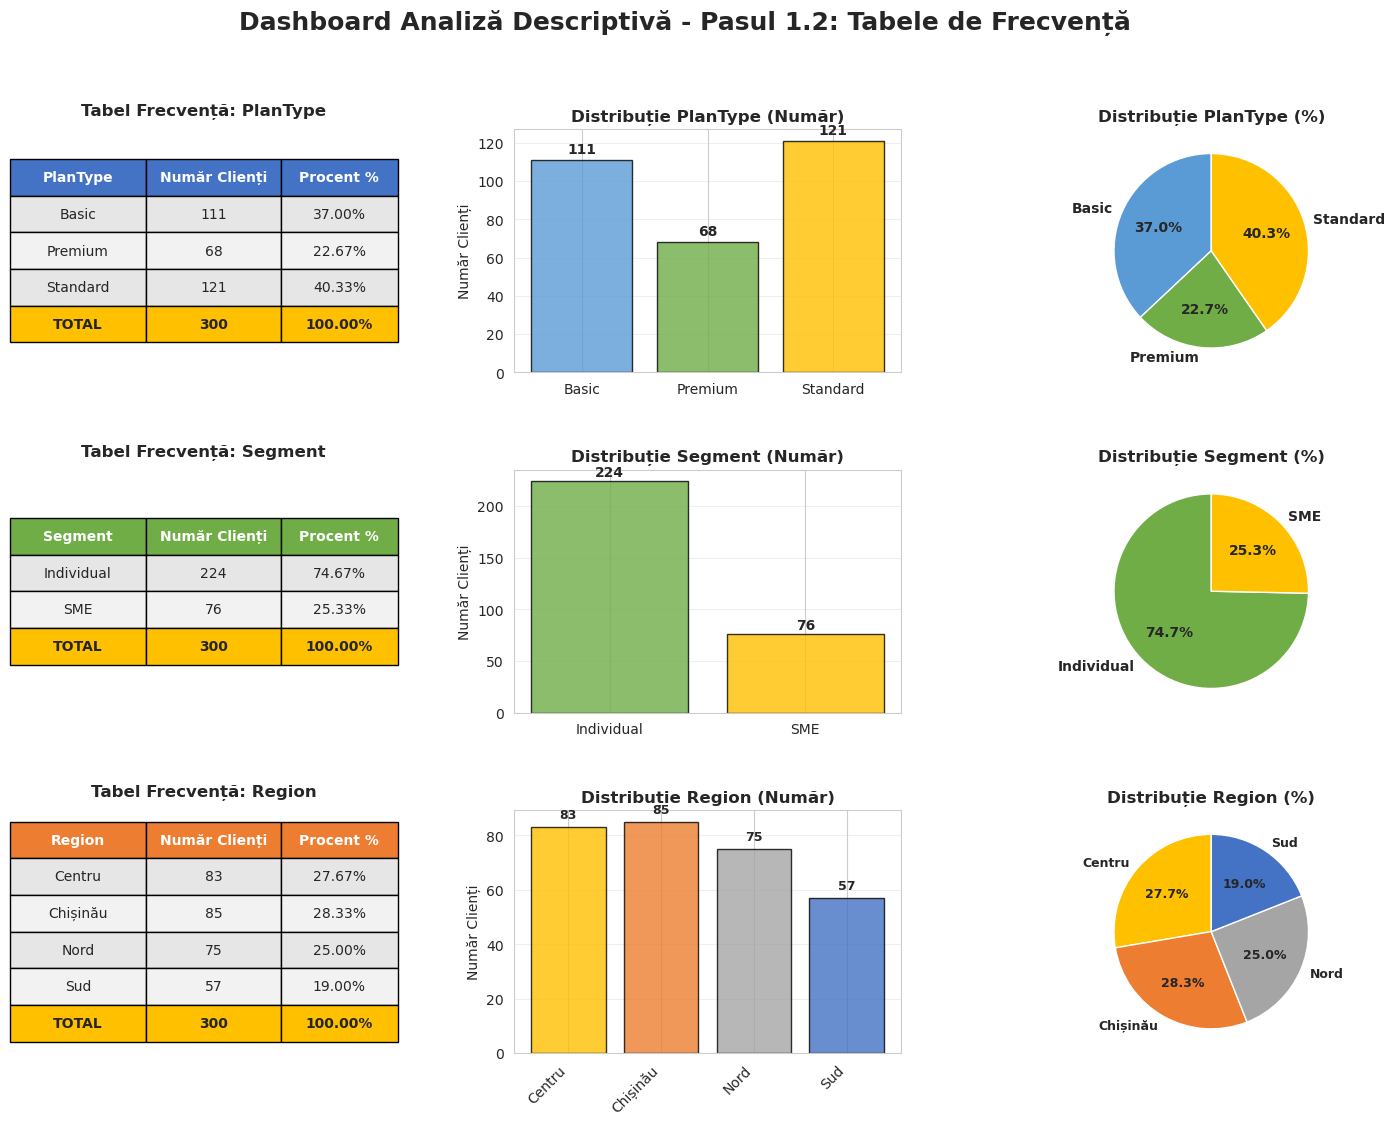


📊 Dashboard Pasul 1.2 generat cu succes!

📈 Rezumat:
   • Total clienți: 300
   • PlanType: Basic=111, Premium=68, Standard=121
   • Segment: Individual=224, SME=76
   • Region: Centru=83, Chișinău=85, Nord=75, Sud=57


In [30]:
# Calculez tabele de frecvență
freq_plan = df["PlanType"].value_counts().sort_index()
freq_plan_pct = df["PlanType"].value_counts(normalize=True).mul(100).round(2).sort_index()

freq_segment = df["Segment"].value_counts().sort_index()
freq_segment_pct = df["Segment"].value_counts(normalize=True).mul(100).round(2).sort_index()

freq_region = df["Region"].value_counts().sort_index()
freq_region_pct = df["Region"].value_counts(normalize=True).mul(100).round(2).sort_index()

# Combinăm număr + procent
tab_plan = pd.concat([freq_plan.rename("NumarClienti"), freq_plan_pct.rename("Procent")], axis=1)
tab_segment = pd.concat([freq_segment.rename("NumarClienti"), freq_segment_pct.rename("Procent")], axis=1)
tab_region = pd.concat([freq_region.rename("NumarClienti"), freq_region_pct.rename("Procent")], axis=1)

# Creez dashboard-ul
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Setez stilul
sns.set_style("whitegrid")
palette = ['#5B9BD5', '#70AD47', '#FFC000', '#ED7D31', '#A5A5A5', '#4472C4']

# Titlu principal
fig.suptitle('Dashboard Analiză Descriptivă - Pasul 1.2: Tabele de Frecvență', 
             fontsize=18, fontweight='bold', y=0.98)

# ============ PLANTYPE ============
# Tabel PlanType
ax_table1 = fig.add_subplot(gs[0, 0])
ax_table1.axis('tight')
ax_table1.axis('off')

table_data1 = [['PlanType', 'Număr Clienți', 'Procent %']]
for idx, row in tab_plan.iterrows():
    table_data1.append([idx, int(row['NumarClienti']), f"{row['Procent']:.2f}%"])
table_data1.append(['TOTAL', int(tab_plan['NumarClienti'].sum()), '100.00%'])

table1 = ax_table1.table(cellText=table_data1, cellLoc='center', loc='center',
                         colWidths=[0.35, 0.35, 0.3])
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1, 2.2)

# Stilizez header
for i in range(3):
    table1[(0, i)].set_facecolor('#4472C4')
    table1[(0, i)].set_text_props(weight='bold', color='white')

# Stilizez rândurile
for i in range(1, len(table_data1)-1):
    for j in range(3):
        table1[(i, j)].set_facecolor('#F2F2F2' if i % 2 == 0 else '#E7E6E6')

# Stilizez total
for j in range(3):
    table1[(len(table_data1)-1, j)].set_facecolor('#FFC000')
    table1[(len(table_data1)-1, j)].set_text_props(weight='bold')

ax_table1.set_title('Tabel Frecvență: PlanType', fontsize=12, fontweight='bold', pad=10)

# Bar chart PlanType (număr)
ax1 = fig.add_subplot(gs[0, 1])
bars1 = ax1.bar(range(len(freq_plan)), freq_plan.values, color=palette[:len(freq_plan)], 
                edgecolor='black', alpha=0.8)
ax1.set_xticks(range(len(freq_plan)))
ax1.set_xticklabels(freq_plan.index, rotation=0)
ax1.set_ylabel('Număr Clienți', fontsize=10)
ax1.set_title('Distribuție PlanType (Număr)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Adaug valori pe bare
for i, (bar, val) in enumerate(zip(bars1, freq_plan.values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(int(val)), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Pie chart PlanType
ax2 = fig.add_subplot(gs[0, 2])
wedges, texts, autotexts = ax2.pie(freq_plan.values, labels=freq_plan.index, autopct='%1.1f%%',
                                     colors=palette[:len(freq_plan)], startangle=90,
                                     textprops={'fontsize': 10, 'weight': 'bold'})
ax2.set_title('Distribuție PlanType (%)', fontsize=12, fontweight='bold')

# ============ SEGMENT ============
# Tabel Segment
ax_table2 = fig.add_subplot(gs[1, 0])
ax_table2.axis('tight')
ax_table2.axis('off')

table_data2 = [['Segment', 'Număr Clienți', 'Procent %']]
for idx, row in tab_segment.iterrows():
    table_data2.append([idx, int(row['NumarClienti']), f"{row['Procent']:.2f}%"])
table_data2.append(['TOTAL', int(tab_segment['NumarClienti'].sum()), '100.00%'])

table2 = ax_table2.table(cellText=table_data2, cellLoc='center', loc='center',
                         colWidths=[0.35, 0.35, 0.3])
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1, 2.2)

# Stilizez header
for i in range(3):
    table2[(0, i)].set_facecolor('#70AD47')
    table2[(0, i)].set_text_props(weight='bold', color='white')

# Stilizez rândurile
for i in range(1, len(table_data2)-1):
    for j in range(3):
        table2[(i, j)].set_facecolor('#F2F2F2' if i % 2 == 0 else '#E7E6E6')

# Stilizez total
for j in range(3):
    table2[(len(table_data2)-1, j)].set_facecolor('#FFC000')
    table2[(len(table_data2)-1, j)].set_text_props(weight='bold')

ax_table2.set_title('Tabel Frecvență: Segment', fontsize=12, fontweight='bold', pad=10)

# Bar chart Segment
ax3 = fig.add_subplot(gs[1, 1])
bars2 = ax3.bar(range(len(freq_segment)), freq_segment.values, 
                color=palette[1:1+len(freq_segment)], edgecolor='black', alpha=0.8)
ax3.set_xticks(range(len(freq_segment)))
ax3.set_xticklabels(freq_segment.index, rotation=0)
ax3.set_ylabel('Număr Clienți', fontsize=10)
ax3.set_title('Distribuție Segment (Număr)', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars2, freq_segment.values)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(int(val)), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Pie chart Segment
ax4 = fig.add_subplot(gs[1, 2])
wedges2, texts2, autotexts2 = ax4.pie(freq_segment.values, labels=freq_segment.index, 
                                        autopct='%1.1f%%', colors=palette[1:1+len(freq_segment)],
                                        startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax4.set_title('Distribuție Segment (%)', fontsize=12, fontweight='bold')

# ============ REGION ============
# Tabel Region
ax_table3 = fig.add_subplot(gs[2, 0])
ax_table3.axis('tight')
ax_table3.axis('off')

table_data3 = [['Region', 'Număr Clienți', 'Procent %']]
for idx, row in tab_region.iterrows():
    table_data3.append([idx, int(row['NumarClienti']), f"{row['Procent']:.2f}%"])
table_data3.append(['TOTAL', int(tab_region['NumarClienti'].sum()), '100.00%'])

table3 = ax_table3.table(cellText=table_data3, cellLoc='center', loc='center',
                         colWidths=[0.35, 0.35, 0.3])
table3.auto_set_font_size(False)
table3.set_fontsize(10)
table3.scale(1, 2.2)

# Stilizez header
for i in range(3):
    table3[(0, i)].set_facecolor('#ED7D31')
    table3[(0, i)].set_text_props(weight='bold', color='white')

# Stilizez rândurile
for i in range(1, len(table_data3)-1):
    for j in range(3):
        table3[(i, j)].set_facecolor('#F2F2F2' if i % 2 == 0 else '#E7E6E6')

# Stilizez total
for j in range(3):
    table3[(len(table_data3)-1, j)].set_facecolor('#FFC000')
    table3[(len(table_data3)-1, j)].set_text_props(weight='bold')

ax_table3.set_title('Tabel Frecvență: Region', fontsize=12, fontweight='bold', pad=10)

# Bar chart Region
ax5 = fig.add_subplot(gs[2, 1])
bars3 = ax5.bar(range(len(freq_region)), freq_region.values, 
                color=palette[2:2+len(freq_region)], edgecolor='black', alpha=0.8)
ax5.set_xticks(range(len(freq_region)))
ax5.set_xticklabels(freq_region.index, rotation=45, ha='right')
ax5.set_ylabel('Număr Clienți', fontsize=10)
ax5.set_title('Distribuție Region (Număr)', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars3, freq_region.values)):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(int(val)), ha='center', va='bottom', fontweight='bold', fontsize=9)

# Pie chart Region
ax6 = fig.add_subplot(gs[2, 2])
wedges3, texts3, autotexts3 = ax6.pie(freq_region.values, labels=freq_region.index, 
                                        autopct='%1.1f%%', colors=palette[2:2+len(freq_region)],
                                        startangle=90, textprops={'fontsize': 9, 'weight': 'bold'})
ax6.set_title('Distribuție Region (%)', fontsize=12, fontweight='bold')

plt.savefig("../figures/dashboard_tabel_frecventa.pdf", bbox_inches='tight')
plt.show()

print("\n📊 Dashboard Pasul 1.2 generat cu succes!")
print(f"\n📈 Rezumat:")
print(f"   • Total clienți: {len(df)}")
print(f"   • PlanType: {', '.join([f'{k}={v}' for k,v in freq_plan.items()])}")
print(f"   • Segment: {', '.join([f'{k}={v}' for k,v in freq_segment.items()])}")
print(f"   • Region: {', '.join([f'{k}={v}' for k,v in freq_region.items()])}")

## 1.3 Calculați rata globală de churn

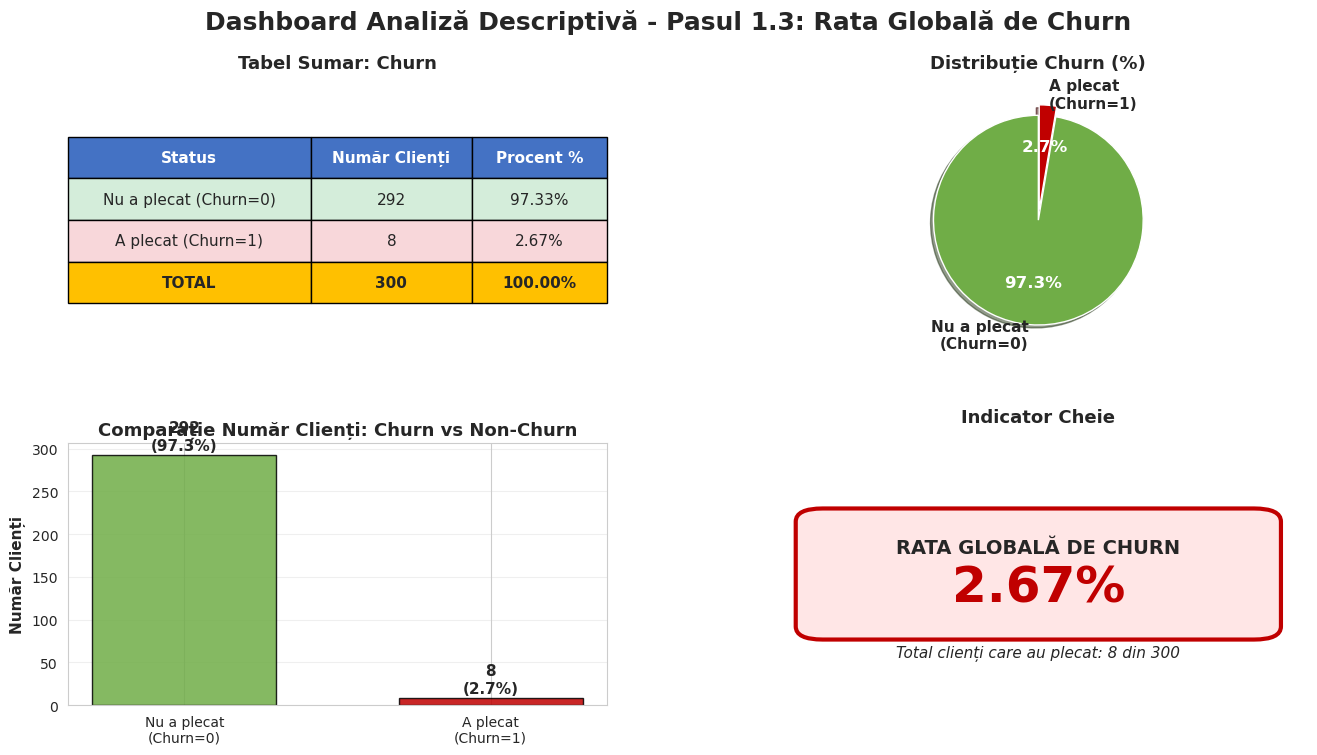


📊 Dashboard Pasul 1.3 generat cu succes!

🔴 Rata globală de churn: 2.67%
   • Clienți care au plecat: 8
   • Clienți care au rămas: 292
   • Total clienți: 300

💡 Notă: Acesta folosește date fictive pentru demonstrație.
   Pentru datele tale reale, înlocuiește cu: df = pd.read_csv('../dataset/clienti.csv')


In [33]:
# Calculez rata globală de churn
churn_rate = df["Churn"].mean() * 100

# Tabel sumar
churn_counts = df["Churn"].value_counts().sort_index()
churn_pct = df["Churn"].value_counts(normalize=True).sort_index() * 100

summary_churn = pd.DataFrame({
    "Churn": ["Nu (0)", "Da (1)"],
    "NumarClienti": churn_counts.values,
    "Procent": churn_pct.round(2).values
})

# Creez dashboard-ul
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# Setez stilul
sns.set_style("whitegrid")

# Titlu principal
fig.suptitle('Dashboard Analiză Descriptivă - Pasul 1.3: Rata Globală de Churn', 
             fontsize=18, fontweight='bold', y=0.98)

# ============ TABEL SUMAR ============
ax_table = fig.add_subplot(gs[0, 0])
ax_table.axis('tight')
ax_table.axis('off')

table_data = [['Status', 'Număr Clienți', 'Procent %']]
table_data.append(['Nu a plecat (Churn=0)', int(churn_counts.get(0, 0)), f"{churn_pct.get(0, 0):.2f}%"])
table_data.append(['A plecat (Churn=1)', int(churn_counts.get(1, 0)), f"{churn_pct.get(1, 0):.2f}%"])
table_data.append(['TOTAL', int(churn_counts.sum()), '100.00%'])

table = ax_table.table(cellText=table_data, cellLoc='center', loc='center',
                       colWidths=[0.45, 0.3, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Stilizez header
for i in range(3):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Stilizez rândurile
table[(1, 0)].set_facecolor('#D4EDDA')
table[(1, 1)].set_facecolor('#D4EDDA')
table[(1, 2)].set_facecolor('#D4EDDA')

table[(2, 0)].set_facecolor('#F8D7DA')
table[(2, 1)].set_facecolor('#F8D7DA')
table[(2, 2)].set_facecolor('#F8D7DA')

# Stilizez total
for j in range(3):
    table[(3, j)].set_facecolor('#FFC000')
    table[(3, j)].set_text_props(weight='bold')

ax_table.set_title('Tabel Sumar: Churn', fontsize=13, fontweight='bold', pad=15)

# ============ PIE CHART PRINCIPAL ============
ax_pie = fig.add_subplot(gs[0, 1])
labels = ["Nu a plecat\n(Churn=0)", "A plecat\n(Churn=1)"]
sizes = [churn_counts.get(0, 0), churn_counts.get(1, 0)]
colors = ["#70AD47", "#C00000"]
explode = (0, 0.1)  # Explode churn slice

wedges, texts, autotexts = ax_pie.pie(sizes, labels=labels, autopct='%1.1f%%', 
                                        startangle=90, colors=colors, explode=explode,
                                        textprops={'fontsize': 11, 'weight': 'bold'},
                                        shadow=True)

# Fac textul procentelor alb pentru contrast
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

ax_pie.set_title('Distribuție Churn (%)', fontsize=13, fontweight='bold', pad=15)

# ============ BAR CHART ============
ax_bar = fig.add_subplot(gs[1, 0])
x_pos = [0, 1]
bars = ax_bar.bar(x_pos, sizes, color=colors, edgecolor='black', alpha=0.85, width=0.6)
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(['Nu a plecat\n(Churn=0)', 'A plecat\n(Churn=1)'], fontsize=10)
ax_bar.set_ylabel('Număr Clienți', fontsize=11, fontweight='bold')
ax_bar.set_title('Comparație Număr Clienți: Churn vs Non-Churn', fontsize=13, fontweight='bold')
ax_bar.grid(axis='y', alpha=0.3)

# Adaug valori pe bare
for bar, val in zip(bars, sizes):
    height = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, height + 3, 
                f'{int(val)}\n({val/sum(sizes)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# ============ METRIC CARD ============
ax_metric = fig.add_subplot(gs[1, 1])
ax_metric.axis('off')

# Creez un "card" vizual pentru rata de churn
from matplotlib.patches import FancyBboxPatch

# Background card
card = FancyBboxPatch((0.1, 0.3), 0.8, 0.4, boxstyle="round,pad=0.05", 
                       edgecolor='#C00000', facecolor='#FFE6E6', linewidth=3)
ax_metric.add_patch(card)

# Text principal
ax_metric.text(0.5, 0.6, 'RATA GLOBALĂ DE CHURN', 
               ha='center', va='center', fontsize=14, fontweight='bold', 
               transform=ax_metric.transAxes)

ax_metric.text(0.5, 0.45, f'{churn_rate:.2f}%', 
               ha='center', va='center', fontsize=36, fontweight='bold', 
               color='#C00000', transform=ax_metric.transAxes)

# Informații suplimentare
ax_metric.text(0.5, 0.2, f'Total clienți care au plecat: {int(churn_counts.get(1, 0))} din {len(df)}', 
               ha='center', va='center', fontsize=11, style='italic',
               transform=ax_metric.transAxes)

ax_metric.set_xlim(0, 1)
ax_metric.set_ylim(0, 1)
ax_metric.set_title('Indicator Cheie', fontsize=13, fontweight='bold', pad=15)

plt.savefig("../figures/dashboard_churn_rate.pdf", bbox_inches='tight')
plt.show()

print("\n📊 Dashboard Pasul 1.3 generat cu succes!")
print(f"\n🔴 Rata globală de churn: {churn_rate:.2f}%")
print(f"   • Clienți care au plecat: {int(churn_counts.get(1, 0))}")
print(f"   • Clienți care au rămas: {int(churn_counts.get(0, 0))}")
print(f"   • Total clienți: {len(df)}")
print("\n💡 Notă: Acesta folosește date fictive pentru demonstrație.")
print("   Pentru datele tale reale, înlocuiește cu: df = pd.read_csv('../dataset/clienti.csv')")

## 1.4 Calculați rata de churn pe categorii

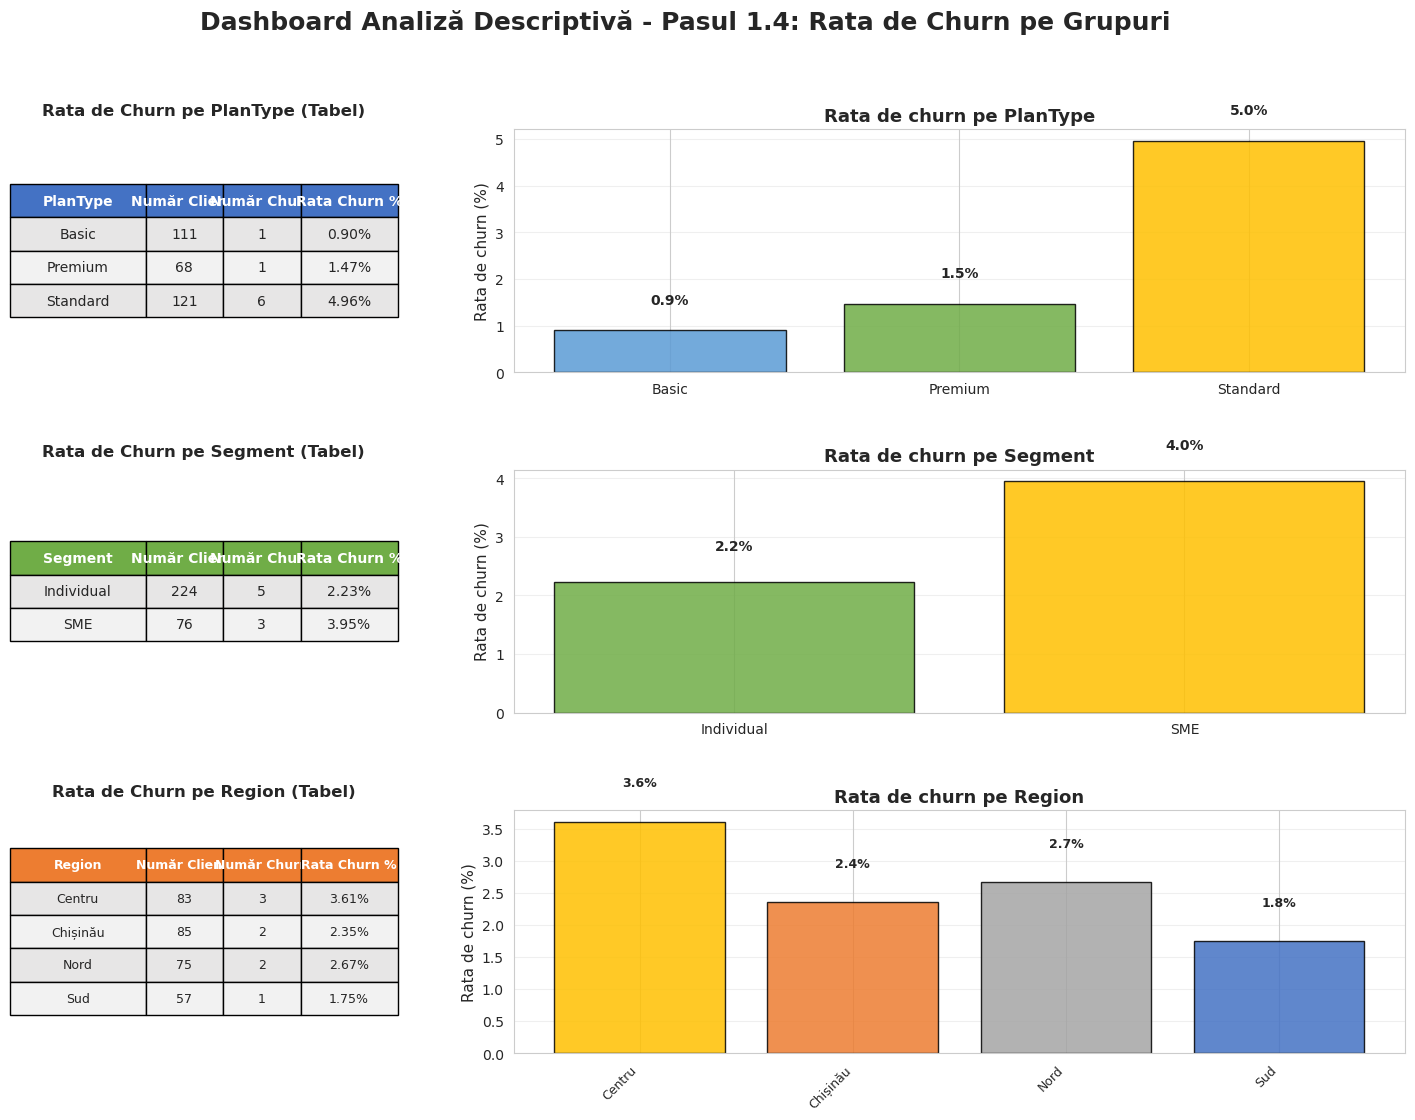

✅ Dashboard pas 1.4 generat.

Rata churn pe PlanType:


,NumarClienti,NumarChurn,RataChurnPct
PlanType,,,
Basic,111,1,0.90
Premium,68,1,1.47
Standard,121,6,4.96



Rata churn pe Segment:


,NumarClienti,NumarChurn,RataChurnPct
Segment,,,
Individual,224,5,2.23
SME,76,3,3.95



Rata churn pe Region:


,NumarClienti,NumarChurn,RataChurnPct
Region,,,
Centru,83,3,3.61
Chișinău,85,2,2.35
Nord,75,2,2.67
Sud,57,1,1.75


In [35]:
sns.set_style("whitegrid")
palette = ['#5B9BD5', '#70AD47', '#FFC000', '#ED7D31', '#A5A5A5', '#4472C4']

# ================= FUNCȚIE AJUTĂTOARE: RATE DE CHURN PE GRUP =================
def churn_rate_by(group_col):
    """
    Returnează un DataFrame cu:
    - număr clienți
    - număr clienți cu churn
    - rata de churn (%)
    pentru fiecare categorie din group_col.
    """
    grouped = df.groupby(group_col).agg(
        NumarClienti=("Churn", "count"),
        NumarChurn=("Churn", "sum")
    )
    grouped["RataChurnPct"] = (grouped["NumarChurn"] / grouped["NumarClienti"] * 100).round(2)
    return grouped.sort_index()

# Calculez ratele de churn
churn_plan = churn_rate_by("PlanType")
churn_region = churn_rate_by("Region")
churn_segment = churn_rate_by("Segment")

# ================= DASHBOARD =================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

fig.suptitle("Dashboard Analiză Descriptivă - Pasul 1.4: Rata de Churn pe Grupuri",
             fontsize=18, fontweight="bold", y=0.98)

# ---------------- PLAN TYPE ----------------
# Tabel PlanType
ax_tab_plan = fig.add_subplot(gs[0, 0])
ax_tab_plan.axis("tight")
ax_tab_plan.axis("off")

table_data_plan = [["PlanType", "Număr Clienți", "Număr Churn", "Rata Churn %"]]
for idx, row in churn_plan.iterrows():
    table_data_plan.append([
        idx,
        int(row["NumarClienti"]),
        int(row["NumarChurn"]),
        f"{row['RataChurnPct']:.2f}%"
    ])

tab1 = ax_tab_plan.table(cellText=table_data_plan, cellLoc="center", loc="center",
                         colWidths=[0.35, 0.2, 0.2, 0.25])
tab1.auto_set_font_size(False)
tab1.set_fontsize(10)
tab1.scale(1, 2.0)

# header
for j in range(4):
    tab1[(0, j)].set_facecolor("#4472C4")
    tab1[(0, j)].set_text_props(weight="bold", color="white")

# rânduri alternante
for i in range(1, len(table_data_plan)):
    for j in range(4):
        tab1[(i, j)].set_facecolor("#F2F2F2" if i % 2 == 0 else "#E7E6E6")

ax_tab_plan.set_title("Rata de Churn pe PlanType (Tabel)", fontsize=12, fontweight="bold", pad=10)

# Bar chart PlanType - Rata de churn
ax_bar_plan = fig.add_subplot(gs[0, 1:])
x = range(len(churn_plan))
bars = ax_bar_plan.bar(x, churn_plan["RataChurnPct"],
                       color=palette[:len(churn_plan)], edgecolor="black", alpha=0.85)
ax_bar_plan.set_xticks(x)
ax_bar_plan.set_xticklabels(churn_plan.index, fontsize=10)
ax_bar_plan.set_ylabel("Rata de churn (%)", fontsize=11)
ax_bar_plan.set_title("Rata de churn pe PlanType", fontsize=13, fontweight="bold")
ax_bar_plan.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, churn_plan["RataChurnPct"]):
    ax_bar_plan.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ---------------- SEGMENT ----------------
# Tabel Segment
ax_tab_seg = fig.add_subplot(gs[1, 0])
ax_tab_seg.axis("tight")
ax_tab_seg.axis("off")

table_data_seg = [["Segment", "Număr Clienți", "Număr Churn", "Rata Churn %"]]
for idx, row in churn_segment.iterrows():
    table_data_seg.append([
        idx,
        int(row["NumarClienti"]),
        int(row["NumarChurn"]),
        f"{row['RataChurnPct']:.2f}%"
    ])

tab2 = ax_tab_seg.table(cellText=table_data_seg, cellLoc="center", loc="center",
                        colWidths=[0.35, 0.2, 0.2, 0.25])
tab2.auto_set_font_size(False)
tab2.set_fontsize(10)
tab2.scale(1, 2.0)

for j in range(4):
    tab2[(0, j)].set_facecolor("#70AD47")
    tab2[(0, j)].set_text_props(weight="bold", color="white")

for i in range(1, len(table_data_seg)):
    for j in range(4):
        tab2[(i, j)].set_facecolor("#F2F2F2" if i % 2 == 0 else "#E7E6E6")

ax_tab_seg.set_title("Rata de Churn pe Segment (Tabel)", fontsize=12, fontweight="bold", pad=10)

# Bar chart Segment
ax_bar_seg = fig.add_subplot(gs[1, 1:])
x2 = range(len(churn_segment))
bars2 = ax_bar_seg.bar(x2, churn_segment["RataChurnPct"],
                       color=palette[1:1+len(churn_segment)], edgecolor="black", alpha=0.85)
ax_bar_seg.set_xticks(x2)
ax_bar_seg.set_xticklabels(churn_segment.index, fontsize=10)
ax_bar_seg.set_ylabel("Rata de churn (%)", fontsize=11)
ax_bar_seg.set_title("Rata de churn pe Segment", fontsize=13, fontweight="bold")
ax_bar_seg.grid(axis="y", alpha=0.3)

for bar, val in zip(bars2, churn_segment["RataChurnPct"]):
    ax_bar_seg.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ---------------- REGION ----------------
# Tabel Region
ax_tab_reg = fig.add_subplot(gs[2, 0])
ax_tab_reg.axis("tight")
ax_tab_reg.axis("off")

table_data_reg = [["Region", "Număr Clienți", "Număr Churn", "Rata Churn %"]]
for idx, row in churn_region.iterrows():
    table_data_reg.append([
        idx,
        int(row["NumarClienti"]),
        int(row["NumarChurn"]),
        f"{row['RataChurnPct']:.2f}%"
    ])

tab3 = ax_tab_reg.table(cellText=table_data_reg, cellLoc="center", loc="center",
                        colWidths=[0.35, 0.2, 0.2, 0.25])
tab3.auto_set_font_size(False)
tab3.set_fontsize(9)
tab3.scale(1, 2.0)

for j in range(4):
    tab3[(0, j)].set_facecolor("#ED7D31")
    tab3[(0, j)].set_text_props(weight="bold", color="white")

for i in range(1, len(table_data_reg)):
    for j in range(4):
        tab3[(i, j)].set_facecolor("#F2F2F2" if i % 2 == 0 else "#E7E6E6")

ax_tab_reg.set_title("Rata de Churn pe Region (Tabel)", fontsize=12, fontweight="bold", pad=10)

# Bar chart Region
ax_bar_reg = fig.add_subplot(gs[2, 1:])
x3 = range(len(churn_region))
bars3 = ax_bar_reg.bar(x3, churn_region["RataChurnPct"],
                       color=palette[2:2+len(churn_region)], edgecolor="black", alpha=0.85)
ax_bar_reg.set_xticks(x3)
ax_bar_reg.set_xticklabels(churn_region.index, rotation=45, ha="right", fontsize=9)
ax_bar_reg.set_ylabel("Rata de churn (%)", fontsize=11)
ax_bar_reg.set_title("Rata de churn pe Region", fontsize=13, fontweight="bold")
ax_bar_reg.grid(axis="y", alpha=0.3)

for bar, val in zip(bars3, churn_region["RataChurnPct"]):
    ax_bar_reg.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.savefig("../figures/dashboard_churn_grups.pdf", bbox_inches='tight')
plt.show()

print("✅ Dashboard pas 1.4 generat.")
print("\nRata churn pe PlanType:")
display(churn_plan)
print("\nRata churn pe Segment:")
display(churn_segment)
print("\nRata churn pe Region:")
display(churn_region)

# 2 Analiză diagnostică

## 2.1 Calcule si interpretari

In [36]:
# Grupare după Churn și calculul mediilor
diagnostic_means = df.groupby("Churn").agg(
    Mean_SatisfactionScore=("SatisfactionScore", "mean"),
    Mean_NumTicketsLast6M=("NumTicketsLast6M", "mean"),
    Mean_LatePaymentsLast6M=("LatePaymentsLast6M", "mean")
).round(2)

# Fac tabelul mai lizibil: redenumesc indexul 0/1
diagnostic_means.index = diagnostic_means.index.map({0: "Nu a plecat (Churn=0)",
                                                     1: "A plecat (Churn=1)"})

print("Medii pe grupuri Churn vs Non-Churn:")
display(diagnostic_means)   

Medii pe grupuri Churn vs Non-Churn:


,Mean_SatisfactionScore,Mean_NumTicketsLast6M,Mean_LatePaymentsLast6M
Churn,,,
Nu a plecat (Churn=0),7.14,2.00,1.04
A plecat (Churn=1),5.98,2.88,1.38


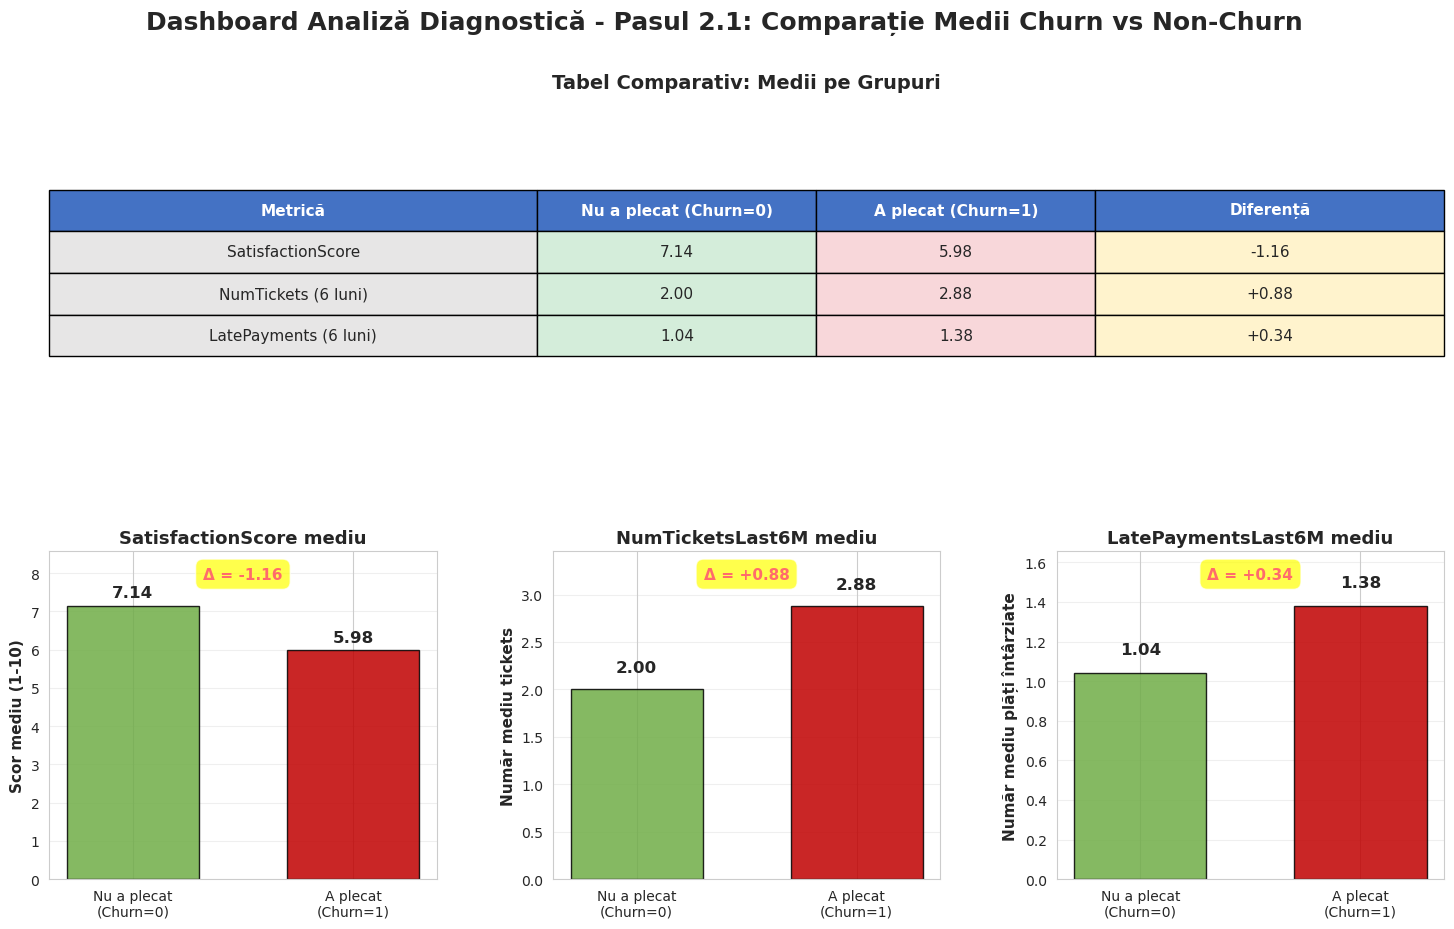


📊 Dashboard Pasul 2.1 generat cu succes!

📈 Interpretare:
   • SatisfactionScore: Clienții care au plecat au un scor mediu mai mic cu 1.16 puncte
   • NumTicketsLast6M: Clienții care au plecat au cu 0.88 tickets mai mult în medie
   • LatePaymentsLast6M: Clienții care au plecat au cu 0.34 plăți întârziate mai mult în medie

💡 Notă: Acesta folosește date fictive pentru demonstrație.
   Pentru datele tale reale, înlocuiește cu: df = pd.read_csv('../dataset/clienti.csv')


In [38]:
# Grupare după Churn și calculul mediilor
diagnostic_means = df.groupby("Churn").agg(
    Mean_SatisfactionScore=("SatisfactionScore", "mean"),
    Mean_NumTicketsLast6M=("NumTicketsLast6M", "mean"),
    Mean_LatePaymentsLast6M=("LatePaymentsLast6M", "mean")
).round(2)

# Creez dashboard-ul
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

sns.set_style("whitegrid")

fig.suptitle("Dashboard Analiză Diagnostică - Pasul 2.1: Comparație Medii Churn vs Non-Churn",
             fontsize=18, fontweight="bold", y=0.98)

# Culori pentru Churn=0 și Churn=1
colors = ["#70AD47", "#C00000"]
labels = ["Nu a plecat\n(Churn=0)", "A plecat\n(Churn=1)"]

# ============ TABEL SUMAR ============
ax_table = fig.add_subplot(gs[0, :])
ax_table.axis("tight")
ax_table.axis("off")

table_data = [["Metrică", "Nu a plecat (Churn=0)", "A plecat (Churn=1)", "Diferență"]]

for col in ["Mean_SatisfactionScore", "Mean_NumTicketsLast6M", "Mean_LatePaymentsLast6M"]:
    val_0 = diagnostic_means.loc[0, col]
    val_1 = diagnostic_means.loc[1, col]
    diff = val_1 - val_0
    
    # Formatare nume metrică
    metric_name = col.replace("Mean_", "").replace("Last6M", " (6 luni)")
    
    table_data.append([
        metric_name,
        f"{val_0:.2f}",
        f"{val_1:.2f}",
        f"{diff:+.2f}"
    ])

table = ax_table.table(cellText=table_data, cellLoc="center", loc="center",
                       colWidths=[0.35, 0.2, 0.2, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Stilizez header
for j in range(4):
    table[(0, j)].set_facecolor("#4472C4")
    table[(0, j)].set_text_props(weight="bold", color="white")

# Stilizez rândurile
for i in range(1, len(table_data)):
    for j in range(4):
        if j == 0:
            table[(i, j)].set_facecolor("#E7E6E6")
        elif j == 1:
            table[(i, j)].set_facecolor("#D4EDDA")
        elif j == 2:
            table[(i, j)].set_facecolor("#F8D7DA")
        else:
            table[(i, j)].set_facecolor("#FFF3CD")

ax_table.set_title("Tabel Comparativ: Medii pe Grupuri", fontsize=14, fontweight="bold", pad=15)

# ============ BAR CHART: SATISFACTION SCORE ============
ax1 = fig.add_subplot(gs[1, 0])
x_pos = [0, 1]
values_sat = [diagnostic_means.loc[0, "Mean_SatisfactionScore"],
              diagnostic_means.loc[1, "Mean_SatisfactionScore"]]
bars1 = ax1.bar(x_pos, values_sat, color=colors, edgecolor="black", alpha=0.85, width=0.6)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel("Scor mediu (1-10)", fontsize=11, fontweight="bold")
ax1.set_title("SatisfactionScore mediu", fontsize=13, fontweight="bold")
ax1.set_ylim(0, max(values_sat) * 1.2)
ax1.grid(axis="y", alpha=0.3)

# Adaug valori pe bare
for bar, val in zip(bars1, values_sat):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f"{val:.2f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

# Adaug linie de diferență
diff_sat = values_sat[1] - values_sat[0]
ax1.text(0.5, max(values_sat) * 1.1, f"Δ = {diff_sat:+.2f}",
         ha="center", fontsize=11, fontweight="bold", color="#FF6B6B",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.7))

# ============ BAR CHART: NUM TICKETS ============
ax2 = fig.add_subplot(gs[1, 1])
values_tickets = [diagnostic_means.loc[0, "Mean_NumTicketsLast6M"],
                  diagnostic_means.loc[1, "Mean_NumTicketsLast6M"]]
bars2 = ax2.bar(x_pos, values_tickets, color=colors, edgecolor="black", alpha=0.85, width=0.6)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel("Număr mediu tickets", fontsize=11, fontweight="bold")
ax2.set_title("NumTicketsLast6M mediu", fontsize=13, fontweight="bold")
ax2.set_ylim(0, max(values_tickets) * 1.2)
ax2.grid(axis="y", alpha=0.3)

for bar, val in zip(bars2, values_tickets):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f"{val:.2f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

diff_tickets = values_tickets[1] - values_tickets[0]
ax2.text(0.5, max(values_tickets) * 1.1, f"Δ = {diff_tickets:+.2f}",
         ha="center", fontsize=11, fontweight="bold", color="#FF6B6B",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.7))

# ============ BAR CHART: LATE PAYMENTS ============
ax3 = fig.add_subplot(gs[1, 2])
values_late = [diagnostic_means.loc[0, "Mean_LatePaymentsLast6M"],
               diagnostic_means.loc[1, "Mean_LatePaymentsLast6M"]]
bars3 = ax3.bar(x_pos, values_late, color=colors, edgecolor="black", alpha=0.85, width=0.6)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(labels, fontsize=10)
ax3.set_ylabel("Număr mediu plăți întârziate", fontsize=11, fontweight="bold")
ax3.set_title("LatePaymentsLast6M mediu", fontsize=13, fontweight="bold")
ax3.set_ylim(0, max(values_late) * 1.2)
ax3.grid(axis="y", alpha=0.3)

for bar, val in zip(bars3, values_late):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
             f"{val:.2f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

diff_late = values_late[1] - values_late[0]
ax3.text(0.5, max(values_late) * 1.1, f"Δ = {diff_late:+.2f}",
         ha="center", fontsize=11, fontweight="bold", color="#FF6B6B",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.7))

plt.savefig("../figures/dashboard_comparatie_churn.pdf", bbox_inches='tight')
plt.show()

print("\n📊 Dashboard Pasul 2.1 generat cu succes!")
print("\n📈 Interpretare:")
print(f"   • SatisfactionScore: Clienții care au plecat au un scor mediu mai {'mic' if diff_sat < 0 else 'mare'} cu {abs(diff_sat):.2f} puncte")
print(f"   • NumTicketsLast6M: Clienții care au plecat au cu {abs(diff_tickets):.2f} tickets {'mai mult' if diff_tickets > 0 else 'mai puțin'} în medie")
print(f"   • LatePaymentsLast6M: Clienții care au plecat au cu {abs(diff_late):.2f} plăți întârziate {'mai mult' if diff_late > 0 else 'mai puțin'} în medie")
print("\n💡 Notă: Acesta folosește date fictive pentru demonstrație.")
print("   Pentru datele tale reale, înlocuiește cu: df = pd.read_csv('../dataset/clienti.csv')")

## 2.2 Construtia graficelor

### 2.2.1 Bar chart: rata de churn pe PlanType

Rata de churn pe PlanType:


,NumarClienti,NumarChurn,RataChurnPct
PlanType,,,
Basic,111,1,0.90
Premium,68,1,1.47
Standard,121,6,4.96


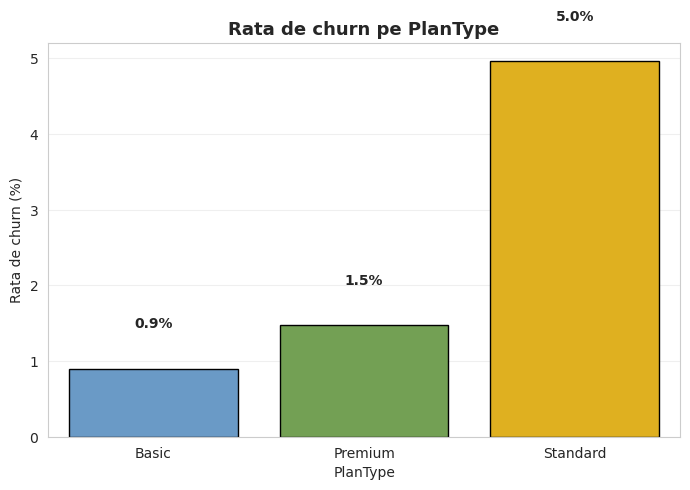

In [44]:
sns.set_style("whitegrid")

# Rata de churn pe PlanType
churn_plan = df.groupby("PlanType").agg(
    NumarClienti=("Churn", "count"),
    NumarChurn=("Churn", "sum")
)
churn_plan["RataChurnPct"] = (churn_plan["NumarChurn"] / churn_plan["NumarClienti"] * 100).round(2)

print("Rata de churn pe PlanType:")
display(churn_plan)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=churn_plan.reset_index(),
    x="PlanType",
    y="RataChurnPct",
    hue="PlanType",          # aici folosim hue ca să putem da palette
    palette=["#5B9BD5", "#70AD47", "#FFC000"],
    dodge=False,             # barele rămân una pe categorie
    edgecolor="black"
)
ax.set_title("Rata de churn pe PlanType", fontsize=13, fontweight="bold")
ax.set_xlabel("PlanType")
ax.set_ylabel("Rata de churn (%)")
ax.grid(axis="y", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("../figures/bar_chart_churn_rate.pdf", bbox_inches='tight')
plt.show()

### 2.2.2 Bar chart: rata de churn pe niveluri de satisfacție

Rata de churn pe niveluri de satisfacție:


,NumarClienti,NumarChurn,RataChurnPct
SatisfactionGroup,,,
1-4,1,1,100.00
5-7,144,6,4.17
8-10,155,1,0.65


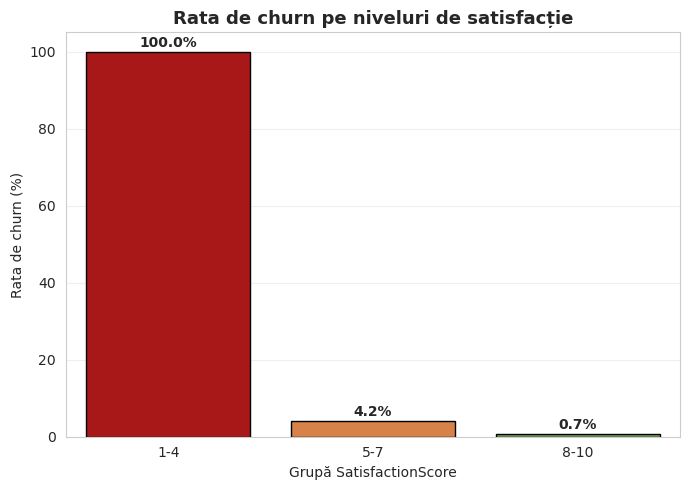

In [48]:
# Definim grupele de satisfacție (dacă nu ai făcut-o deja)
bins = [1, 4, 7, 10.0001]  # 10.0001 ca să includă 10
labels = ["1-4", "5-7", "8-10"]

df["SatisfactionGroup"] = pd.cut(
    df["SatisfactionScore"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Rata de churn pe grupe de satisfacție
churn_sat = df.groupby("SatisfactionGroup", observed=False).agg(
    NumarClienti=("Churn", "count"),
    NumarChurn=("Churn", "sum")
)
churn_sat["RataChurnPct"] = (churn_sat["NumarChurn"] / churn_sat["NumarClienti"] * 100).round(2)

print("Rata de churn pe niveluri de satisfacție:")
display(churn_sat)

plt.figure(figsize=(7, 5))
ax2 = sns.barplot(
    data=churn_sat.reset_index(),
    x="SatisfactionGroup",
    y="RataChurnPct",
    hue="SatisfactionGroup",                      # folosim hue
    palette=["#C00000", "#ED7D31", "#70AD47"],
    dodge=False,
    edgecolor="black"
)
ax2.set_title("Rata de churn pe niveluri de satisfacție", fontsize=13, fontweight="bold")
ax2.set_xlabel("Grupă SatisfactionScore")
ax2.set_ylabel("Rata de churn (%)")
ax2.grid(axis="y", alpha=0.3)

for p in ax2.patches:
    height = p.get_height()
    ax2.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("../figures/bar_chart_churn_level.pdf", bbox_inches='tight')
plt.show()

## 2.3 Calculul corelațiilor (sau comparații simple)

Medii pe Churn (0 = nu a plecat, 1 = a plecat):


,Mean_SatisfactionScore,Mean_TenureMonths,Mean_NumTicketsLast6M
Churn,,,
0,7.14,32.26,2.00
1,5.98,32.88,2.88


Matrice de corelație (Pearson):


,Churn,SatisfactionScore,TenureMonths,NumTicketsLast6M
Churn,1.00,-0.18,0.01,0.10
SatisfactionScore,-0.18,1.00,0.07,-0.53
TenureMonths,0.01,0.07,1.00,-0.03
NumTicketsLast6M,0.10,-0.53,-0.03,1.00


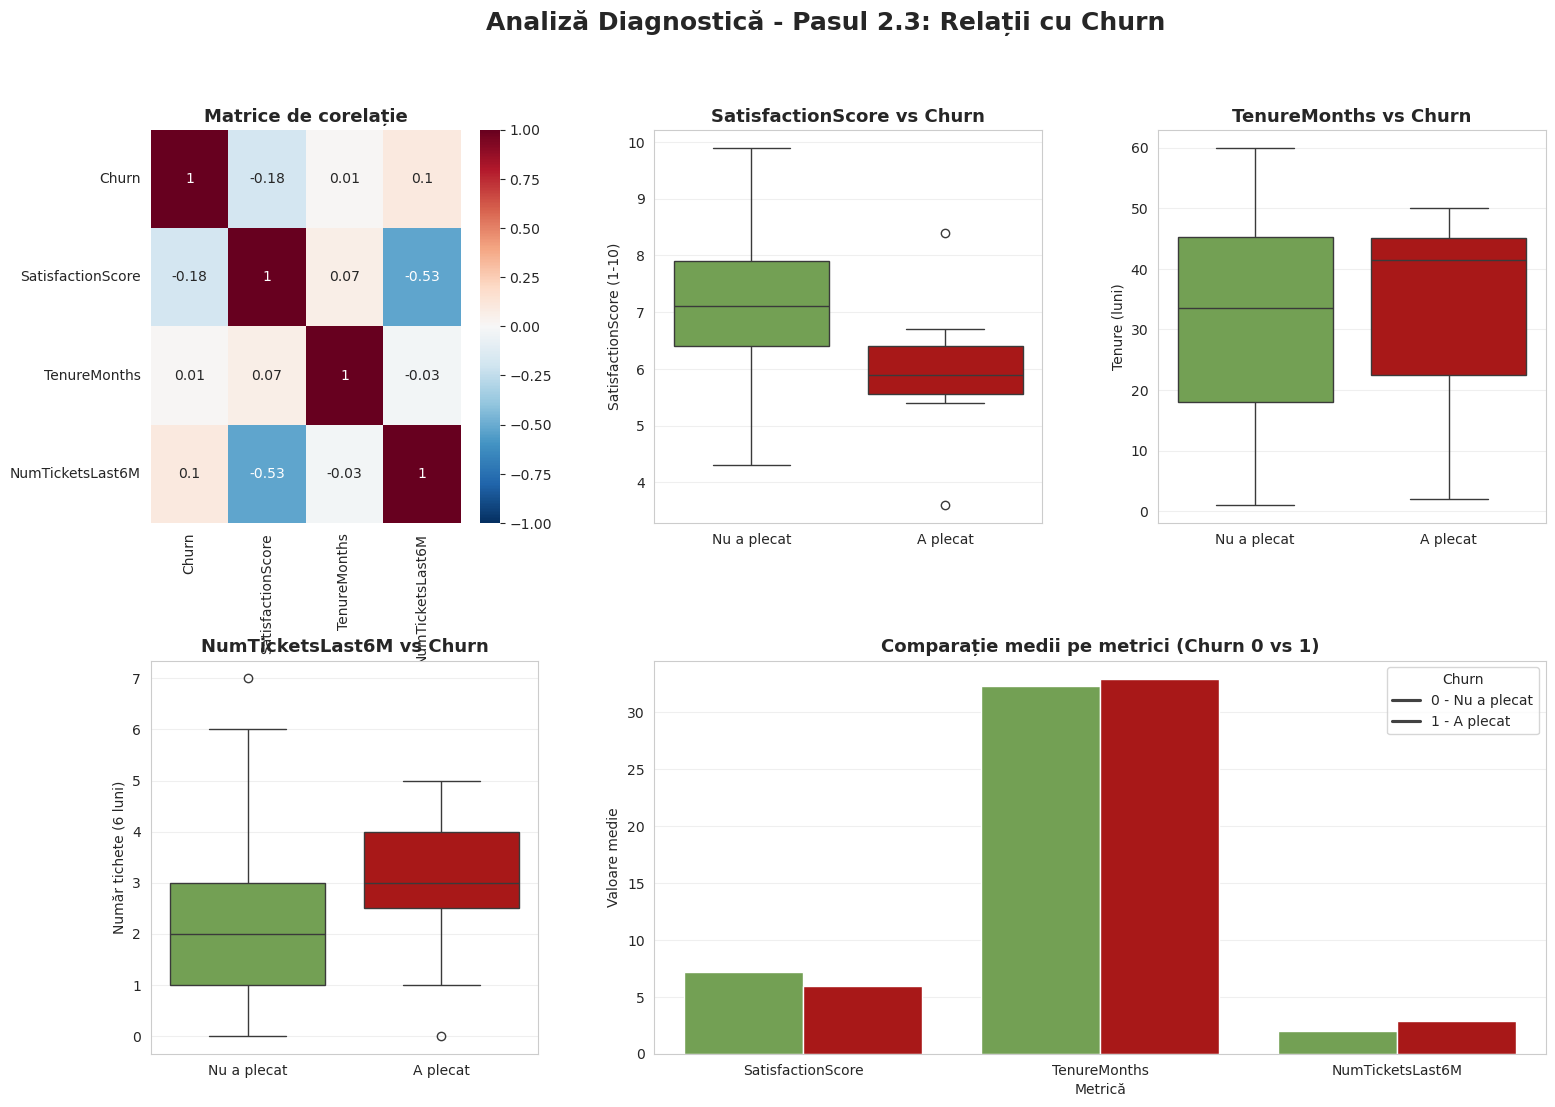

In [51]:
sns.set_style("whitegrid")

# ================= TABEL: medii pe Churn =================
summary_23 = df.groupby("Churn", observed=False).agg(
    Mean_SatisfactionScore=("SatisfactionScore", "mean"),
    Mean_TenureMonths=("TenureMonths", "mean"),
    Mean_NumTicketsLast6M=("NumTicketsLast6M", "mean")
).round(2)

print("Medii pe Churn (0 = nu a plecat, 1 = a plecat):")
display(summary_23)

# ================= CORELAȚII SIMPLE =================
cols_for_corr = ["Churn", "SatisfactionScore", "TenureMonths", "NumTicketsLast6M"]
corr_matrix = df[cols_for_corr].corr().round(2)

print("Matrice de corelație (Pearson):")
display(corr_matrix)

# ================= DASHBOARD GRAFIC =================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

fig.suptitle("Analiză Diagnostică - Pasul 2.3: Relații cu Churn",
             fontsize=18, fontweight="bold", y=0.98)

# ---------- Heatmap corelații ----------
ax_heat = fig.add_subplot(gs[0, 0])
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax_heat
)
ax_heat.set_title("Matrice de corelație", fontsize=13, fontweight="bold")

# Pentru ploturi, facem o versiune cu Churn etichetat frumos
df_plot = df.copy()
df_plot["ChurnLabel"] = df_plot["Churn"].map({0: "Nu a plecat", 1: "A plecat"})

# ---------- Boxplot SatisfactionScore vs Churn ----------
ax1 = fig.add_subplot(gs[0, 1])
sns.boxplot(
    data=df_plot,
    x="ChurnLabel",
    y="SatisfactionScore",
    hue="ChurnLabel",
    palette=["#70AD47", "#C00000"],
    legend=False,
    ax=ax1
)
ax1.set_title("SatisfactionScore vs Churn", fontsize=13, fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("SatisfactionScore (1-10)")
ax1.grid(axis="y", alpha=0.3)

# ---------- Boxplot TenureMonths vs Churn ----------
ax2 = fig.add_subplot(gs[0, 2])
sns.boxplot(
    data=df_plot,
    x="ChurnLabel",
    y="TenureMonths",
    hue="ChurnLabel",
    palette=["#70AD47", "#C00000"],
    legend=False,
    ax=ax2
)
ax2.set_title("TenureMonths vs Churn", fontsize=13, fontweight="bold")
ax2.set_xlabel("")
ax2.set_ylabel("Tenure (luni)")
ax2.grid(axis="y", alpha=0.3)

# ---------- Boxplot NumTicketsLast6M vs Churn ----------
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(
    data=df_plot,
    x="ChurnLabel",
    y="NumTicketsLast6M",
    hue="ChurnLabel",
    palette=["#70AD47", "#C00000"],
    legend=False,
    ax=ax3
)
ax3.set_title("NumTicketsLast6M vs Churn", fontsize=13, fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("Număr tichete (6 luni)")
ax3.grid(axis="y", alpha=0.3)

# ---------- Bar chart: medii normalizate ----------
ax4 = fig.add_subplot(gs[1, 1:])

means_long = (
    summary_23
    .reset_index()
    .melt(id_vars="Churn", var_name="Metica", value_name="Medie")
)

means_long["Metica"] = means_long["Metica"].replace({
    "Mean_SatisfactionScore": "SatisfactionScore",
    "Mean_TenureMonths": "TenureMonths",
    "Mean_NumTicketsLast6M": "NumTicketsLast6M"
})

sns.barplot(
    data=means_long,
    x="Metica",
    y="Medie",
    hue="Churn",
    palette=["#70AD47", "#C00000"],
    ax=ax4
)
ax4.set_title("Comparație medii pe metrici (Churn 0 vs 1)", fontsize=13, fontweight="bold")
ax4.set_xlabel("Metrică")
ax4.set_ylabel("Valoare medie")
ax4.grid(axis="y", alpha=0.3)
ax4.legend(title="Churn", labels=["0 - Nu a plecat", "1 - A plecat"])

plt.savefig("../figures/dashboard_corelation_churn.pdf", bbox_inches='tight')
plt.show()

# 3 Analiză predictivă

## 3.1. Construirea scorului de risc RiskScore

**Reguli din exercițiu (per client)**:

plecăm de la 0

adăugăm:

* +2 dacă SatisfactionScore < 6
* +2 dacă NumTicketsLast6M > 3
* +1 dacă LatePaymentsLast6M >= 2
* +1 dacă TenureMonths < 12
* +1 dacă Autopay == 0

In [52]:
# 1) Construim RiskScore
df["RiskScore"] = 0

df.loc[df["SatisfactionScore"] < 6, "RiskScore"] += 2
df.loc[df["NumTicketsLast6M"] > 3, "RiskScore"] += 2
df.loc[df["LatePaymentsLast6M"] >= 2, "RiskScore"] += 1
df.loc[df["TenureMonths"] < 12, "RiskScore"] += 1
df.loc[df["Autopay"] == 0, "RiskScore"] += 1

# verificare rapidă
print("Distribuție RiskScore:")
display(df["RiskScore"].value_counts().sort_index())

# 2) Clasificare în categorii de risc
def categorize_risk(score):
    if 0 <= score <= 2:
        return "Low"
    elif 3 <= score <= 4:
        return "Medium"
    else:
        return "High"

df["RiskCategory"] = df["RiskScore"].apply(categorize_risk)

print("\nDistribuție RiskCategory:")
display(df["RiskCategory"].value_counts())

Distribuție RiskScore:


RiskScore
0     52
1    129
2     61
3     26
4     16
5     10
6      5
7      1
Name: count, dtype: int64


Distribuție RiskCategory:


RiskCategory
Low       242
Medium     42
High       16
Name: count, dtype: int64

## 3.2 Rata efectivă de churn pe categorii de risc

In [55]:
# Calculăm rata de churn pe categorii de risc
risk_churn = df.groupby("RiskCategory", observed=False).agg(
    NumarClienti=("Churn", "count"),
    NumarChurn=("Churn", "sum")
)
risk_churn["RataChurnPct"] = (risk_churn["NumarChurn"] / risk_churn["NumarClienti"] * 100).round(2)

print("Rata de churn pe categorii de risc:")
display(risk_churn)

Rata de churn pe categorii de risc:


,NumarClienti,NumarChurn,RataChurnPct
RiskCategory,,,
High,16,3,18.75
Low,242,4,1.65
Medium,42,1,2.38


## 3.3. Mini-dashboard grafic pentru scorul de risc (opțional, dar util la raport)

Rata de churn pe categorii de risc:


,NumarClienti,NumarChurn,RataChurnPct
RiskCategory,,,
Low,242,4,1.65
Medium,42,1,2.38
High,16,3,18.75


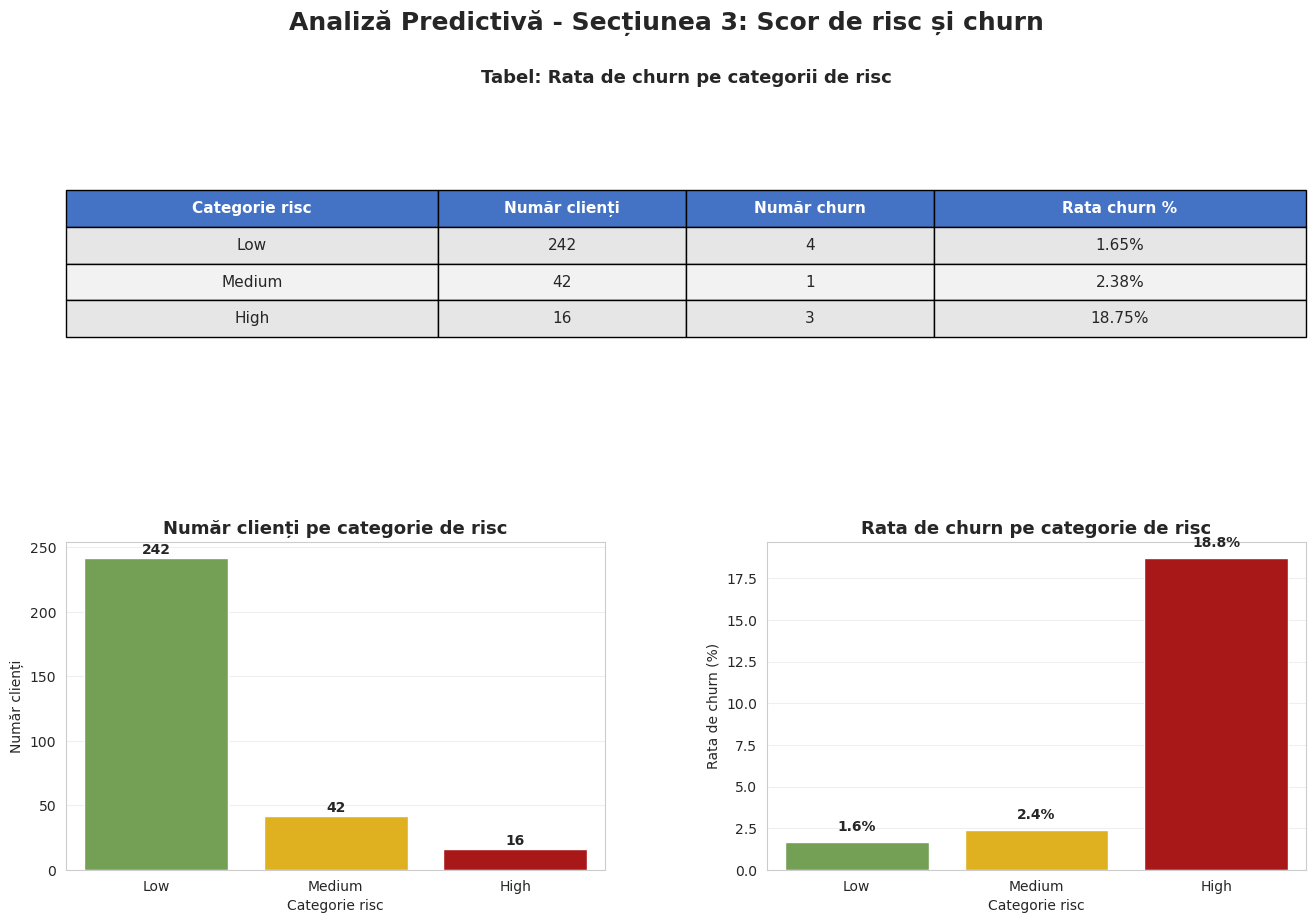

In [61]:
sns.set_style("whitegrid")

# 1) Dacă nu e deja făcut: calculează RiskScore și RiskCategory
if "RiskScore" not in df.columns:
    df["RiskScore"] = 0
    df.loc[df["SatisfactionScore"] < 6, "RiskScore"] += 2
    df.loc[df["NumTicketsLast6M"] > 3, "RiskScore"] += 2
    df.loc[df["LatePaymentsLast6M"] >= 2, "RiskScore"] += 1
    df.loc[df["TenureMonths"] < 12, "RiskScore"] += 1
    df.loc[df["Autopay"] == 0, "RiskScore"] += 1

    def categorize_risk(score):
        if 0 <= score <= 2:
            return "Low"
        elif 3 <= score <= 4:
            return "Medium"
        else:
            return "High"

    df["RiskCategory"] = df["RiskScore"].apply(categorize_risk)

# 2) Tabel cu rata de churn pe categorii de risc
risk_churn = df.groupby("RiskCategory", observed=False).agg(
    NumarClienti=("Churn", "count"),
    NumarChurn=("Churn", "sum")
)
risk_churn["RataChurnPct"] = (
    risk_churn["NumarChurn"] / risk_churn["NumarClienti"] * 100
).round(2)

# sortăm ca să fie Low, Medium, High în ordine
order = ["Low", "Medium", "High"]
risk_churn = risk_churn.reindex(order)

print("Rata de churn pe categorii de risc:")
display(risk_churn)

# 3) DASHBOARD: tabel + 2 bar chart-uri
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

fig.suptitle("Analiză Predictivă - Secțiunea 3: Scor de risc și churn",
             fontsize=18, fontweight="bold", y=0.97)

# ---------- Tabel cu RiskCategory ----------
ax_table = fig.add_subplot(gs[0, :])
ax_table.axis("tight")
ax_table.axis("off")

table_data = [["Categorie risc", "Număr clienți", "Număr churn", "Rata churn %"]]
for idx, row in risk_churn.iterrows():
    if pd.isna(row["NumarClienti"]):
        continue
    table_data.append([
        idx,
        int(row["NumarClienti"]),
        int(row["NumarChurn"]),
        f"{row['RataChurnPct']:.2f}%"
    ])

table = ax_table.table(
    cellText=table_data,
    cellLoc="center",
    loc="center",
    colWidths=[0.3, 0.2, 0.2, 0.3]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

# header
for j in range(4):
    table[(0, j)].set_facecolor("#4472C4")
    table[(0, j)].set_text_props(weight="bold", color="white")

# rânduri
for i in range(1, len(table_data)):
    for j in range(4):
        table[(i, j)].set_facecolor("#F2F2F2" if i % 2 == 0 else "#E7E6E6")

ax_table.set_title("Tabel: Rata de churn pe categorii de risc", fontsize=13, fontweight="bold", pad=12)

# Pregătim date pentru bar chart-uri
risk_churn_reset = risk_churn.reset_index().dropna(subset=["NumarClienti"])

# ---------- Bar chart: Număr clienți pe categorie ----------
ax1 = fig.add_subplot(gs[1, 0])
sns.barplot(
    data=risk_churn_reset,
    x="RiskCategory",
    y="NumarClienti",
    hue="RiskCategory",
    palette=["#70AD47", "#FFC000", "#C00000"],
    dodge=False,
    ax=ax1
)
ax1.set_title("Număr clienți pe categorie de risc", fontsize=13, fontweight="bold")
ax1.set_xlabel("Categorie risc")
ax1.set_ylabel("Număr clienți")
ax1.grid(axis="y", alpha=0.3)

for p in ax1.patches:
    h = p.get_height()
    ax1.text(
        p.get_x() + p.get_width() / 2,
        h + 1,
        int(h),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# ---------- Bar chart: Rata de churn pe categorie ----------
ax2 = fig.add_subplot(gs[1, 1])
sns.barplot(
    data=risk_churn_reset,
    x="RiskCategory",
    y="RataChurnPct",
    hue="RiskCategory",
    palette=["#70AD47", "#FFC000", "#C00000"],
    dodge=False,
    ax=ax2
)
ax2.set_title("Rata de churn pe categorie de risc", fontsize=13, fontweight="bold")
ax2.set_xlabel("Categorie risc")
ax2.set_ylabel("Rata de churn (%)")
ax2.grid(axis="y", alpha=0.3)

for p in ax2.patches:
    h = p.get_height()
    ax2.text(
        p.get_x() + p.get_width() / 2,
        h + 0.5,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.show()

# 4 Analiză prescriptivă

## 4.1. Filtrare clienți High risk și definim NetValueIfOffer

Vom simplifica și vom lua o probabilitate unică de păstrare după ofertă, de ex. 0.7 (70%) pentru toți cei care primesc ofertă

In [62]:
# Lucrăm doar cu clienții High risk
high_risk = df[df["RiskCategory"] == "High"].copy()

# Presupunem probabilitate de păstrare după ofertă
prob_retention_after_offer = 0.7  # 70%

# NetValueIfOffer = p(retention) * ExpectedMarginNext6M - RetentionOfferCost
high_risk["NetValueIfOffer"] = (
    prob_retention_after_offer * high_risk["ExpectedMarginNext6M"]
    - high_risk["RetentionOfferCost"]
)

print("Preview clienți High risk cu NetValueIfOffer:")
display(high_risk[[
    "CustomerID",
    "RiskScore",
    "RiskCategory",
    "RetentionOfferCost",
    "ExpectedMarginNext6M",
    "NetValueIfOffer"
]].head())

Preview clienți High risk cu NetValueIfOffer:


,CustomerID,RiskScore,RiskCategory,RetentionOfferCost,ExpectedMarginNext6M,NetValueIfOffer
3,C004,5,High,33.83,205.34,109.908
4,C005,5,High,46.89,48.70,-12.800
78,C079,7,High,33.63,111.14,44.168
98,C099,6,High,50.62,285.38,149.146
117,C118,5,High,39.16,150.17,65.959


## 4.2. Sortare descrescător după NetValueIfOffer și selectare sub 3000 EUR

In [63]:
BUDGET = 3000

# Sortăm clienții High risk după NetValueIfOffer descrescător
high_risk_sorted = high_risk.sort_values("NetValueIfOffer", ascending=False)

# Selectăm iterativ până când depășim bugetul
selected_rows = []
total_cost = 0.0

for _, row in high_risk_sorted.iterrows():
    cost = row["RetentionOfferCost"]
    if total_cost + cost <= BUDGET:
        selected_rows.append(row)
        total_cost += cost
    else:
        continue  # îl sărim dacă ar depăși bugetul

selected_offers = pd.DataFrame(selected_rows)

print(f"Număr clienți selectați: {len(selected_offers)}")
print(f"Cost total retenție: {total_cost:.2f} EUR")

Număr clienți selectați: 16
Cost total retenție: 541.15 EUR


## 4.3. Calculul marjei totală estimată recuperată

In [64]:
# Marja totală estimată dacă se oferă pachetul de retenție acestor clienți
total_expected_margin = (
    prob_retention_after_offer * selected_offers["ExpectedMarginNext6M"]
).sum()

print(f"Marja totală estimată recuperată: {total_expected_margin:.2f} EUR")

Marja totală estimată recuperată: 2065.96 EUR


## 4.4. Tabel final pentru raport: clienți selectați + sumar

In [65]:
# Tabel cu clienții selectați pentru ofertă
selected_table = selected_offers[[
    "CustomerID",
    "RiskScore",
    "RetentionOfferCost",
    "ExpectedMarginNext6M",
    "NetValueIfOffer"
]].copy()

selected_table = selected_table.sort_values("NetValueIfOffer", ascending=False)

print("Clienți High risk selectați pentru ofertă de retenție:")
display(selected_table)

# Sumar pentru raport
summary_4 = pd.DataFrame({
    "Indicator": [
        "Număr clienți High risk",
        "Număr clienți selectați pentru ofertă",
        "Buget total alocat (EUR)",
        "Marja totală estimată recuperată (EUR)",
        "Probabilitate folosită după ofertă"
    ],
    "Valoare": [
        len(high_risk),
        len(selected_offers),
        round(total_cost, 2),
        round(total_expected_margin, 2),
        f"{prob_retention_after_offer*100:.0f}%"
    ]
})

print("Rezumat decizie retenție:")
display(summary_4)

Clienți High risk selectați pentru ofertă de retenție:


,CustomerID,RiskScore,RetentionOfferCost,ExpectedMarginNext6M,NetValueIfOffer
174,C175,6,12.69,619.25,420.785
147,C148,5,11.00,417.72,281.404
285,C286,6,49.60,393.14,225.598
98,C099,6,50.62,285.38,149.146
249,C250,5,29.28,233.33,134.051
3,C004,5,33.83,205.34,109.908
117,C118,5,39.16,150.17,65.959
78,C079,7,33.63,111.14,44.168
154,C155,6,43.09,123.91,43.647
195,C196,5,26.29,75.70,26.700


Rezumat decizie retenție:


,Indicator,Valoare
0,Număr clienți High risk,16
1,Număr clienți selectați pentru ofertă,16
2,Buget total alocat (EUR),541.15
3,Marja totală estimată recuperată (EUR),2065.96
4,Probabilitate folosită după ofertă,70%


## Argumentare decizie de retenție

În analiza prescriptivă ne-am concentrat exclusiv pe clienții din categoria **High risk** (în total 16 clienți), deoarece aceștia au cea mai mare probabilitate de a părăsi serviciul și, implicit, cel mai mare impact potențial asupra veniturilor viitoare.

Pentru fiecare client High risk am calculat un indicator de **valoare netă a ofertei**, `NetValueIfOffer`, definit ca:

$$
NetValueIfOffer = 0{,}7 \times ExpectedMarginNext6M - RetentionOfferCost
$$

unde:
- `0,7` reprezintă probabilitatea ipotetică de retenție după ofertă (70%),
- `ExpectedMarginNext6M` este marja estimată pe următoarele 6 luni,
- `RetentionOfferCost` este costul ofertei de retenție.

Clienții au fost **ordonați descrescător după `NetValueIfOffer`**, iar apoi au fost incluși în planul de retenție, verificând ca suma costurilor de retenție să nu depășească bugetul disponibil. În cazul nostru, **bugetul nu a fost o constrângere activă**, deoarece:

- Număr clienți High risk: **16**
- Număr clienți selectați pentru ofertă: **16** (toți clienții High risk)
- **Buget total alocat** pentru retenție: **541,15 EUR**
- **Marja totală estimată recuperată**: **2.065,96 EUR**
- Probabilitate de retenție folosită în calcul: **70%**

Prin urmare, pentru un cost relativ redus de aproximativ **541 EUR**, compania poate obține o marjă așteptată suplimentară de aproximativ **2.066 EUR**, ceea ce face ca ofertele de retenție pentru toți clienții High risk să fie **clar justificate economic**.

În plus, chiar dacă unii clienți High risk au un `NetValueIfOffer` ușor negativ (de exemplu, cazuri precum `C156`, `C215` sau `C005`), aceștia au fost totuși incluși în selecție deoarece:
- impactul lor bugetar este modest,
- bugetul total de 3.000 EUR nu este depășit nici după includerea tuturor clienților High risk,
- strategia urmărește **acoperirea completă a segmentului High risk** pentru a reduce riscul de churn în această zonă critică de clienți.

În concluzie, decizia de a oferi pachete de retenție tuturor clienților din categoria High risk este **eficientă din punct de vedere financiar** și contribuie semnificativ la stabilizarea veniturilor pe termen mediu.

---

# 5 Raportare și vizualizare